## Reddit Mental Health Discussions - Exploratory Data Analysis (EDA)

### This script performs exploratory data analysis (EDA) on a dataset containing Reddit posts related to mental health.

### Sections:
1. Load Dataset
2. Data Cleaning & Preprocessing
3. Text Processing (Tokenization, Lemmatization)
4. Word Cloud Visualization
5. Subreddit-Specific Word Clouds
6. Medication Mentions Analysis
7. Time Series Analysis
8. User Engagement & Subreddit Activity Analysis
9. N-Gram Analysis (Bigrams & Trigrams)
10. Post Frequency by Date & Disease Category
11. Top Authors and Their Subreddits
12. Posting Frequency of Top 3 Authors by Subreddit

### Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import nltk
import string
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
from collections import Counter
from nltk import ngrams

In [2]:
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# Load spaCy model for lemmatization
nlp = spacy.load("en_core_web_sm")

In [4]:
# 1️⃣ Load Dataset
file_path = "/content/reddit_posts_combined_26Jan_07Mar.csv"
df = pd.read_csv(file_path)
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
# Display dataset information
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17725 entries, 0 to 17724
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Author              17615 non-null  object 
 1   Created_UTC         17725 non-null  float64
 2   Created_DateTime    17725 non-null  object 
 3   Score               17725 non-null  int64  
 4   Selftext            17635 non-null  object 
 5   Tokenized_Selftext  17725 non-null  object 
 6   Subreddit           17725 non-null  object 
 7   Title               17725 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 1.1+ MB


,Author,Created_UTC,Created_DateTime,Score,Selftext,Tokenized_Selftext,Subreddit,Title
0,mamboitalianoo,1.738359e+09,2025-01-31 21:32:39,1,A couple years ago I had a bout of panic attac...,"['A', 'couple', 'years', 'ago', 'I', 'had', 'a...",Anxiety,Panic attack or vertigo?
1,Midori_sho,1.738359e+09,2025-01-31 21:31:03,1,School has been kicking my ass lately. My midt...,"['School', 'has', 'been', 'kicking', 'my', 'as...",Anxiety,I think I’m actually stupid as hell
2,No_Entrepreneur_4395,1.738359e+09,2025-01-31 21:29:09,1,"I've never been diagnosed by a doctor, but I'm...","['I', ""'ve"", 'never', 'been', 'diagnosed', 'by...",Anxiety,Is being medicated better?
3,Successful-Bat-5287,1.738359e+09,2025-01-31 21:22:31,1,Long time anxiety sufferer here. I’ve done the...,"['Long', 'time', 'anxiety', 'sufferer', 'here'...",Anxiety,My body is anxious but I’m not?
4,ratherdream,1.738358e+09,2025-01-31 21:07:44,1,I'm so afraid of losing the ones I love and my...,"['I', ""'m"", 'so', 'afraid', 'of', 'losing', 't...",Anxiety,Afraid to loose people


In [6]:
# 2️⃣ Data Cleaning & Preprocessing
# Check for missing values
df.isnull().sum()

,0
Author,110
Created_UTC,0
Created_DateTime,0
Score,0
Selftext,90
Tokenized_Selftext,0
Subreddit,0
Title,0


In [7]:
# Fill missing values
df.dropna(subset=['Selftext'], inplace=True)  # Remove rows with null 'Selftext'
df['Author'] = df['Author'].fillna('Anonymous')  # Replace missing authors with 'Anonymous'
print("Missing values handled")

Missing values handled


In [8]:
# Save cleaned dataset
cleaned_file_path = "/content/reddit_posts_26Jan-07Mar_cleaned.csv"
df.to_csv(cleaned_file_path, index=False)
print(f"Cleaned dataset saved at: {cleaned_file_path}")

Cleaned dataset saved at: /content/reddit_posts_26Jan-07Mar_cleaned.csv


In [30]:
# 3️⃣ Text Processing (Tokenization, Lemmatization)
def clean_and_tokenize(text):
    """Tokenize and clean text by removing stopwords and punctuation."""
    if pd.isna(text):
        return ""
    text = text.lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(tokens)

df["New_Token_Selftext"] = df["Selftext"].apply(clean_and_tokenize)

def lemmatize_text(text):
    """Perform lemmatization on the text using spaCy."""
    if isinstance(text, str):
        doc = nlp(text)
        return " ".join([token.lemma_ for token in doc])
    return text

df['Lemmatized_Text'] = df['New_Token_Selftext'].apply(lemmatize_text)
df['Merged_Lemma_Token'] = df['Lemmatized_Text']

df.to_csv("/content/reddit_posts_processed_07Mar.csv", index=False)

In [10]:
# 4️⃣ Word Cloud Visualization
def generate_wordcloud(text, title):
    """Generate and display a word cloud."""
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()

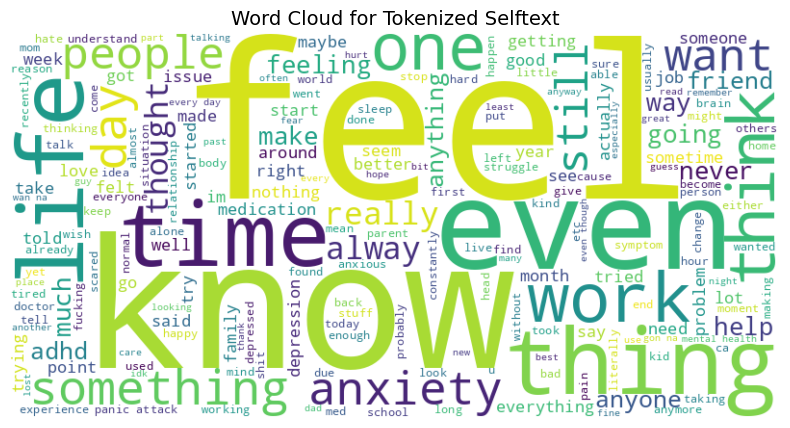

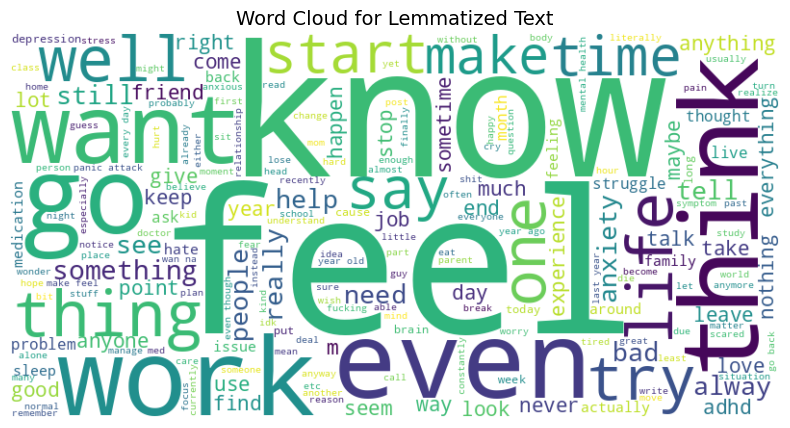

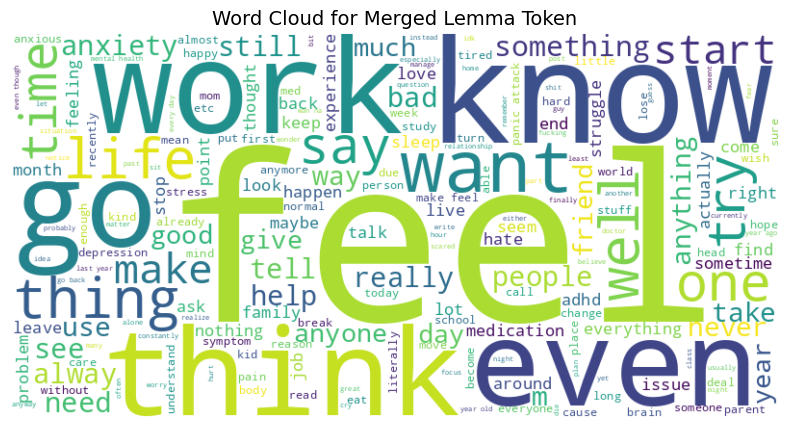

In [11]:
# Generate word clouds
generate_wordcloud(" ".join(df['New_Token_Selftext'].dropna()), "Word Cloud for Tokenized Selftext")
generate_wordcloud(" ".join(df['Lemmatized_Text'].dropna()), "Word Cloud for Lemmatized Text")
generate_wordcloud(" ".join(df['Merged_Lemma_Token'].dropna()), "Word Cloud for Merged Lemma Token")

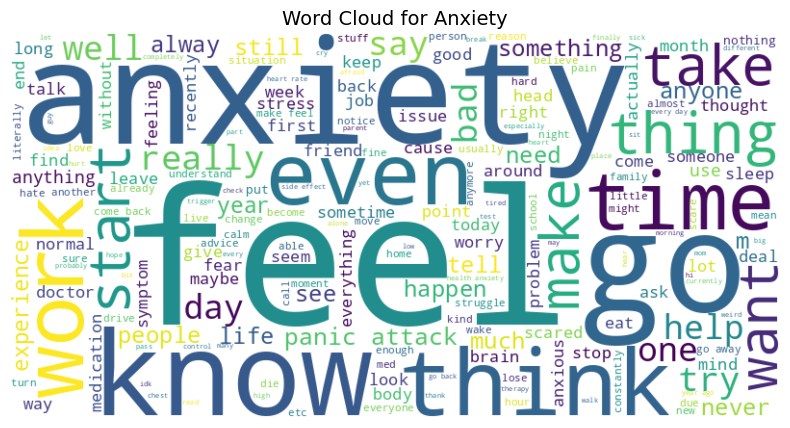

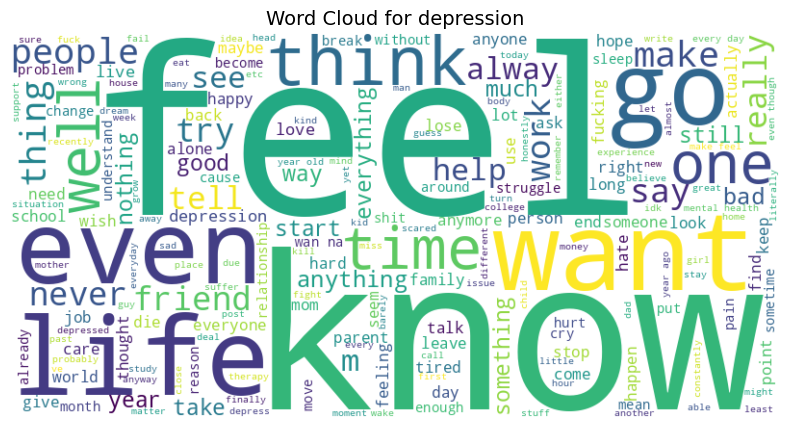

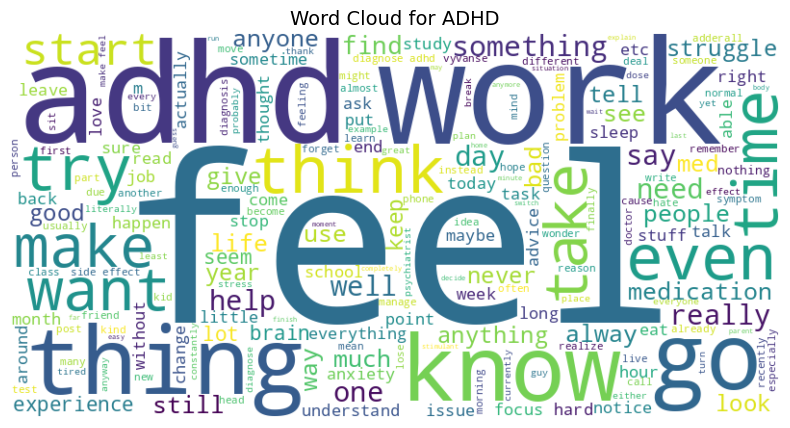

In [12]:
# 5️⃣ Subreddit-Specific Word Clouds
subreddits = ["Anxiety", "depression", "ADHD"]
for sub in subreddits:
    sub_data = df[df['Subreddit'] == sub]
    text_data = " ".join(sub_data['Merged_Lemma_Token'].dropna())
    if text_data.strip():
        generate_wordcloud(text_data, f"Word Cloud for {sub}")
    else:
        print(f"No text data available for {sub} subreddit.")

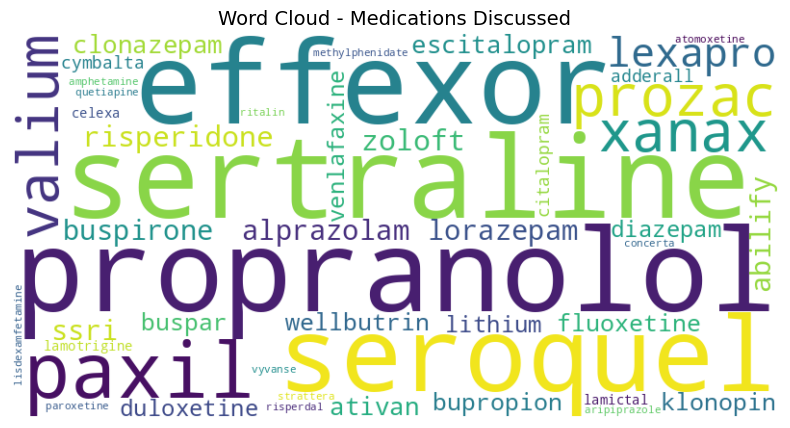

In [13]:
# 6️⃣ Medication Mentions Analysis
medication_list = {"prozac", "fluoxetine", "lexapro", "escitalopram", "zoloft", "sertraline", "paxil", "paroxetine",
    "celexa", "citalopram", "wellbutrin", "bupropion", "effexor", "venlafaxine", "cymbalta", "duloxetine",
    "abilify", "aripiprazole", "risperdal", "risperidone", "lamictal", "lamotrigine", "vyvanse", "lisdexamfetamine",
    "adderall", "amphetamine", "ritalin", "methylphenidate", "concerta", "strattera", "atomoxetine",
    "xanax", "alprazolam", "klonopin", "clonazepam", "ativan", "lorazepam", "valium", "diazepam",
    "seroquel", "quetiapine", "lithium", "buspar", "buspirone", "propranolol", "ssri"}

medication_counts = Counter()

for text in df["New_Token_Selftext"].dropna():
    tokens = word_tokenize(text.lower())
    filtered_meds = [word for word in tokens if word in medication_list]
    medication_counts.update(filtered_meds)

generate_wordcloud(" ".join(medication_counts.keys()), "Word Cloud - Medications Discussed")

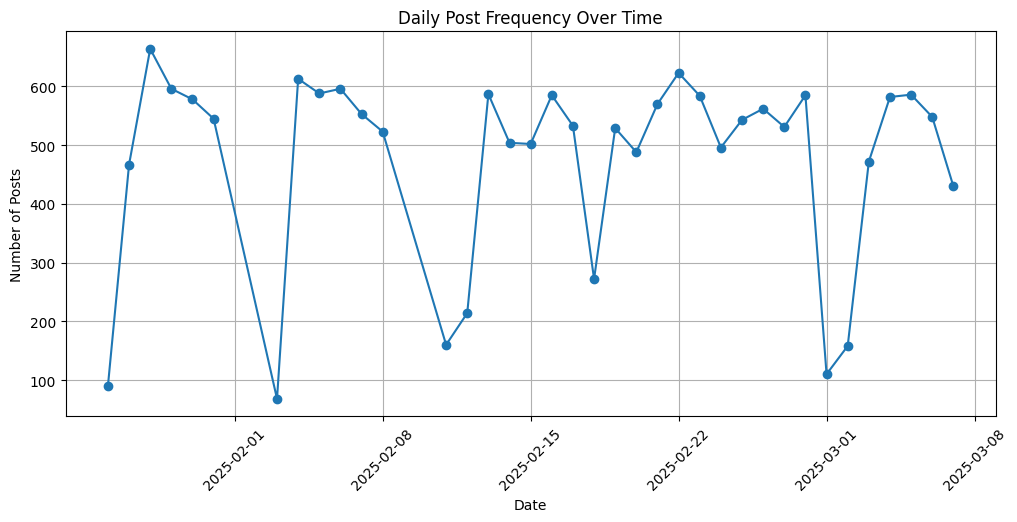

In [14]:
# 7️⃣ Time Series Analysis
df['Created_DateTime'] = pd.to_datetime(df['Created_DateTime'])
df['Date'] = df['Created_DateTime'].dt.date

daily_posts = df.groupby('Date').size()
plt.figure(figsize=(12, 5))
plt.plot(daily_posts.index, daily_posts.values, marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.title("Daily Post Frequency Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

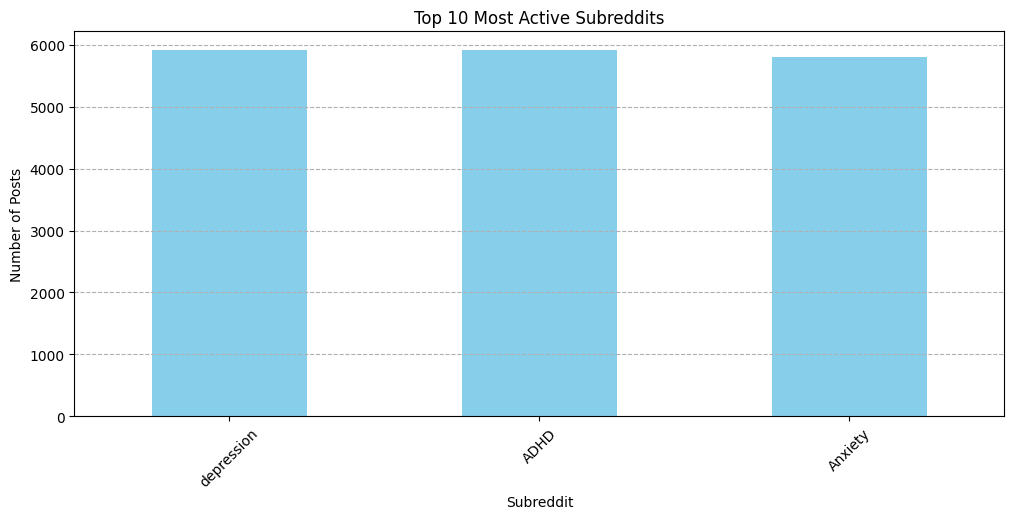

In [15]:
# 8️⃣ User Engagement & Subreddit Activity Analysis
top_subreddits = df['Subreddit'].value_counts().head(10)
top_subreddits.plot(kind='bar', color='skyblue', figsize=(12,5))
plt.xlabel("Subreddit")
plt.ylabel("Number of Posts")
plt.title("Top 10 Most Active Subreddits")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

In [22]:
# 9️⃣ N-Gram Analysis (Bigrams & Trigrams)
import pandas as pd
from nltk import ngrams
from collections import Counter
import matplotlib.pyplot as plt

In [23]:
def get_ngrams(text, n):
    if pd.isna(text):  # Check for NaN
        return []
    if isinstance(text, str):  # Ensure text is a string
        words = text.split()
        return list(ngrams(words, n))
    return []  # Return empty list for non-string types

In [24]:
# Dictionary to store n-gram frequencies by subreddit
bigram_freq_by_subreddit = {}
trigram_freq_by_subreddit = {}

In [25]:
# Extract bigrams and trigrams by subreddit
for subreddit in df['Subreddit'].unique():
    subreddit_df = df[df['Subreddit'] == subreddit]
    all_bigrams = []
    all_trigrams = []
    for text in subreddit_df['New_Token_Selftext']:
        bigrams = get_ngrams(text, 2)
        trigrams = get_ngrams(text, 3)
        all_bigrams.extend(bigrams)
        all_trigrams.extend(trigrams)
    bigram_freq_by_subreddit[subreddit] = Counter(all_bigrams)
    trigram_freq_by_subreddit[subreddit] = Counter(all_trigrams)

In [26]:
# Convert to DataFrames and get top 10 for each subreddit
bigram_dfs = {}
trigram_dfs = {}

In [27]:
for subreddit in df['Subreddit'].unique():
    bigram_df = pd.DataFrame(bigram_freq_by_subreddit[subreddit].items(), columns=['Bigram', 'Frequency'])
    bigram_df['Bigram'] = bigram_df['Bigram'].apply(lambda x: ' '.join(x))  # Convert tuple to string
    bigram_df = bigram_df.sort_values(by=['Frequency', 'Bigram'], ascending=[False, True]).head(10).reset_index(drop=True)
    bigram_dfs[subreddit] = bigram_df

    trigram_df = pd.DataFrame(trigram_freq_by_subreddit[subreddit].items(), columns=['Trigram', 'Frequency'])
    trigram_df['Trigram'] = trigram_df['Trigram'].apply(lambda x: ' '.join(x))  # Convert tuple to string
    trigram_df = trigram_df.sort_values(by=['Frequency', 'Trigram'], ascending=[False, True]).head(10).reset_index(drop=True)
    trigram_dfs[subreddit] = trigram_df

In [28]:
# Display the tables
for subreddit in df['Subreddit'].unique():
    print(f"\nTop 10 Bigrams Table for {subreddit}:")
    print(bigram_dfs[subreddit].to_string(index=False))
    print(f"\nTop 10 Trigrams Table for {subreddit}:")
    print(trigram_dfs[subreddit].to_string(index=False))


Top 10 Bigrams Table for Anxiety:
        Bigram  Frequency
     feel like       1837
 panic attacks        703
   anyone else        699
  panic attack        685
    feels like        620
     felt like        397
health anxiety        359
    heart rate        350
        gon na        334
     every day        292

Top 10 Trigrams Table for Anxiety:
                Trigram  Frequency
anyone else experienced         85
        feel like going         81
  anxiety panic attacks         78
           feel like im         65
 anyone else experience         60
       long story short         56
       every single day         51
  wondering anyone else         49
     really bad anxiety         48
        anyone else get         46

Top 10 Bigrams Table for depression:
       Bigram  Frequency
    feel like       2854
   feels like        673
       wan na        582
    every day        490
mental health        414
       gon na        377
   get better        364
  even though       

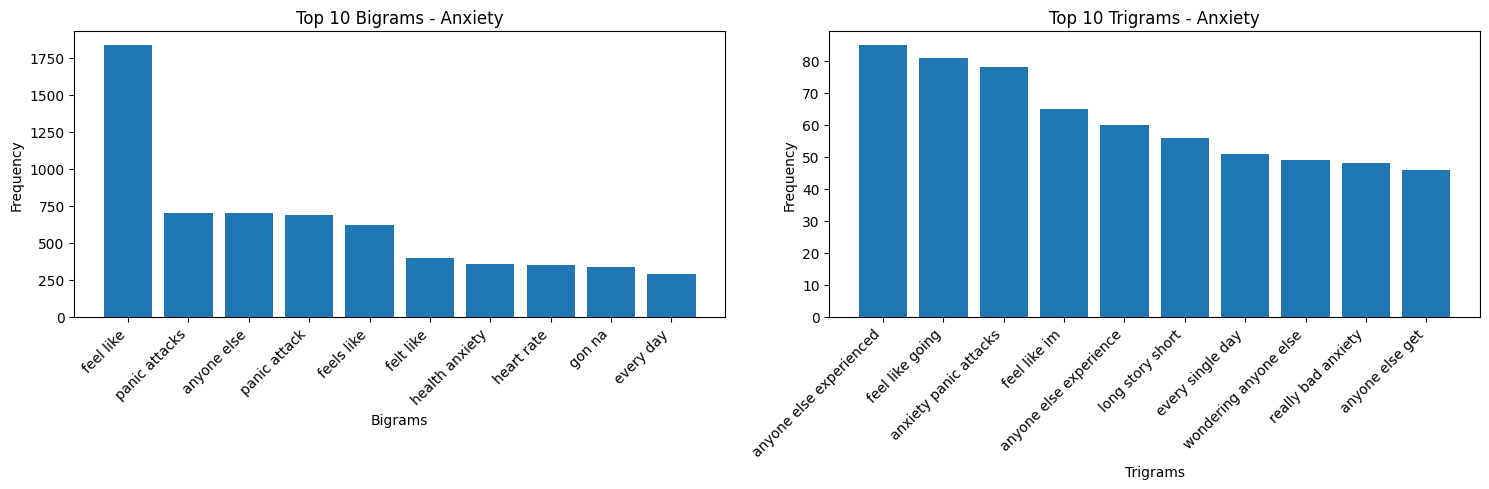

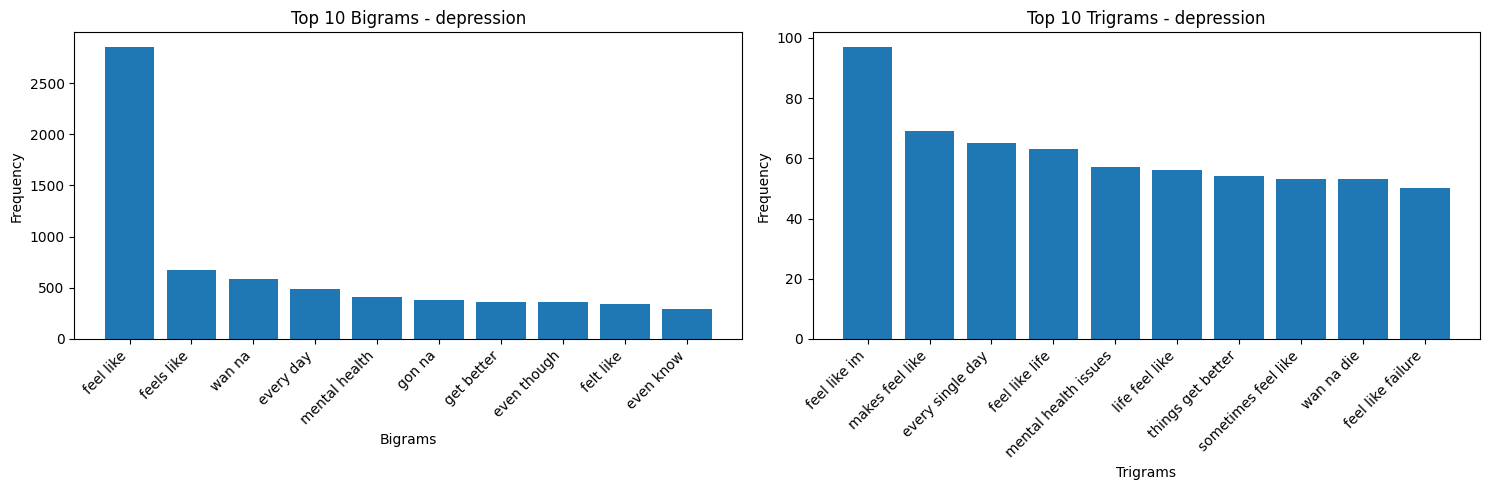

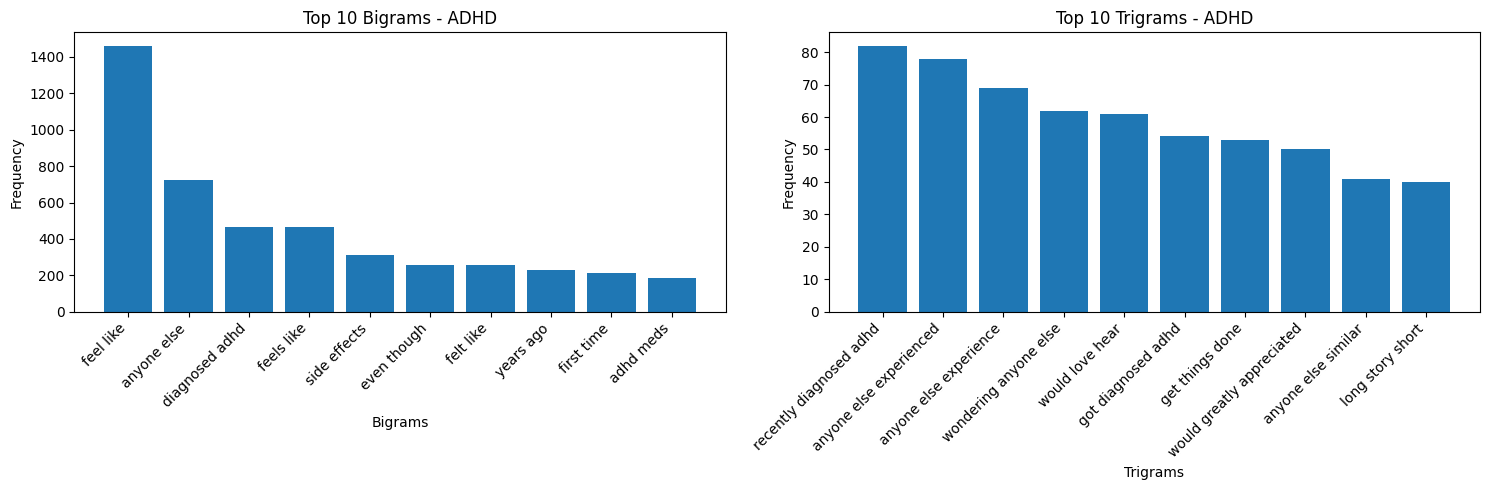

In [29]:
# Generate bar plots for each subreddit
for subreddit in df['Subreddit'].unique():
    plt.figure(figsize=(15, 5))

    # Bar plot for bigrams
    plt.subplot(1, 2, 1)
    plt.bar(bigram_dfs[subreddit]['Bigram'], bigram_dfs[subreddit]['Frequency'])
    plt.title(f'Top 10 Bigrams - {subreddit}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Bigrams')
    plt.ylabel('Frequency')

    # Bar plot for trigrams
    plt.subplot(1, 2, 2)
    plt.bar(trigram_dfs[subreddit]['Trigram'], trigram_dfs[subreddit]['Frequency'])
    plt.title(f'Top 10 Trigrams - {subreddit}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Trigrams')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

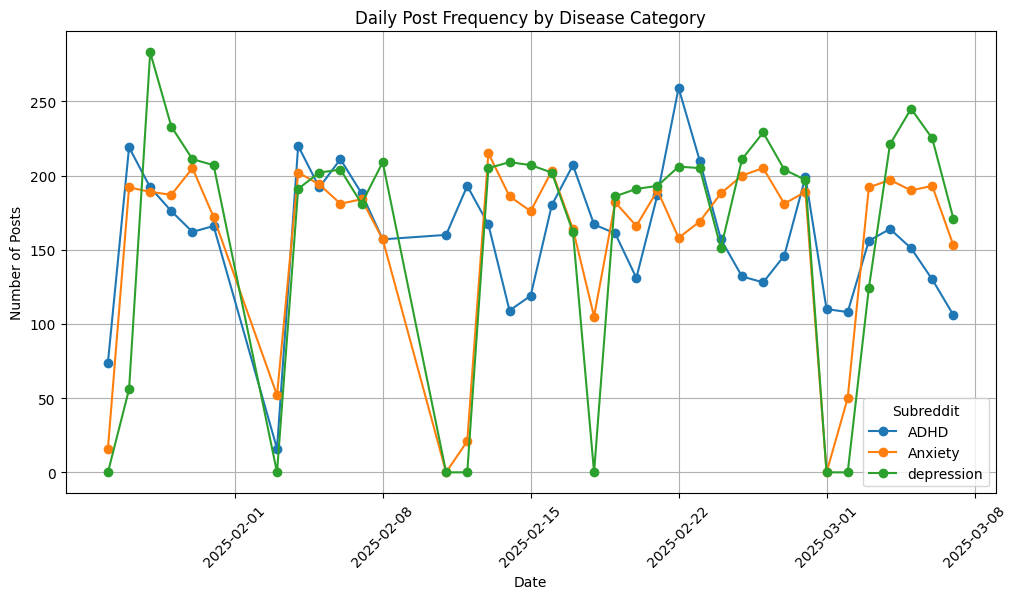

In [17]:
# 1️⃣0️⃣ Post Frequency by Date & Disease Category
disease_posts = df.groupby(['Date', 'Subreddit']).size().unstack().fillna(0)
disease_posts.plot(kind='line', figsize=(12, 6), marker='o')
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.title("Daily Post Frequency by Disease Category")
plt.xticks(rotation=45)
plt.legend(title='Subreddit')
plt.grid(True)
plt.show()

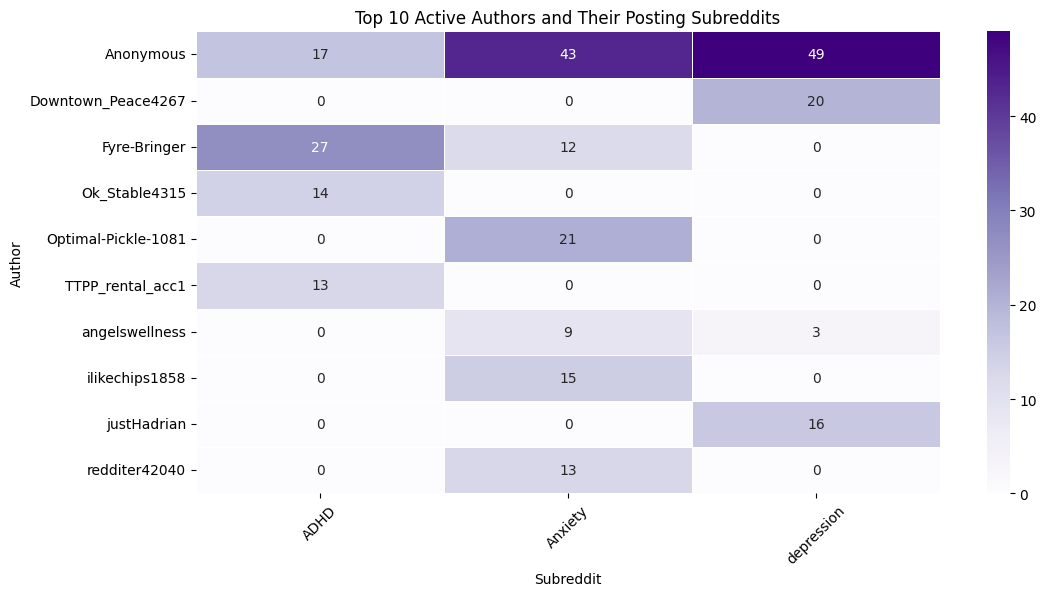

In [18]:
# 1️⃣1️⃣ Top Authors and Their Subreddits
top_authors = df['Author'].value_counts().head(10)
top_authors_df = df[df['Author'].isin(top_authors.index)]
author_subreddit_counts = top_authors_df.groupby(['Author', 'Subreddit']).size().unstack().fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(author_subreddit_counts, annot=True, fmt='g', cmap='Purples', linewidths=0.5)
plt.xlabel("Subreddit")
plt.ylabel("Author")
plt.title("Top 10 Active Authors and Their Posting Subreddits")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

<ipython-input-19-5d202cca2511>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  author_df['Created_DateTime'] = pd.to_datetime(author_df['Created_DateTime'])
<ipython-input-19-5d202cca2511>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  author_df['Date'] = author_df['Created_DateTime'].dt.date


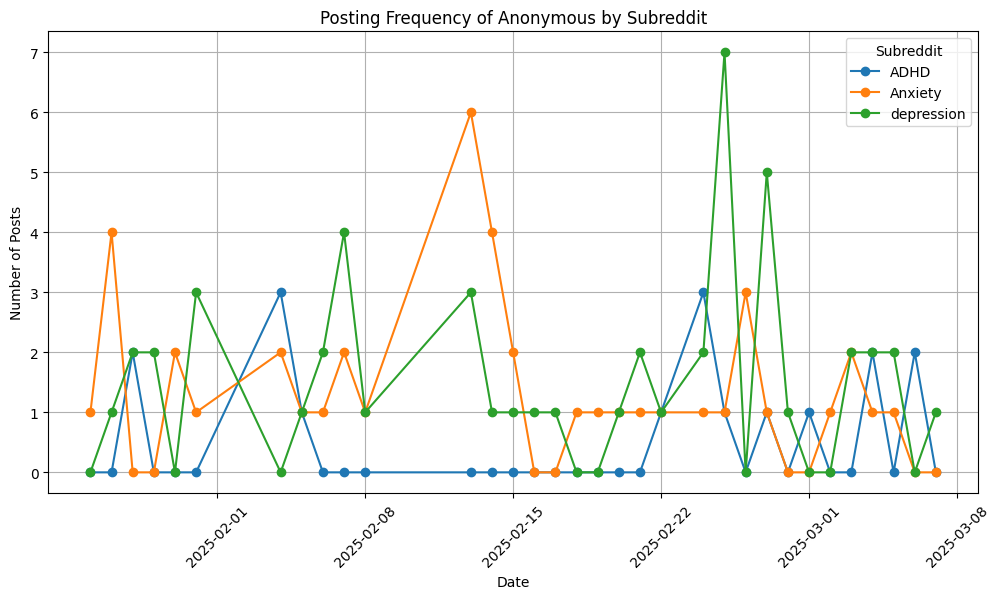

<ipython-input-19-5d202cca2511>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  author_df['Created_DateTime'] = pd.to_datetime(author_df['Created_DateTime'])
<ipython-input-19-5d202cca2511>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  author_df['Date'] = author_df['Created_DateTime'].dt.date


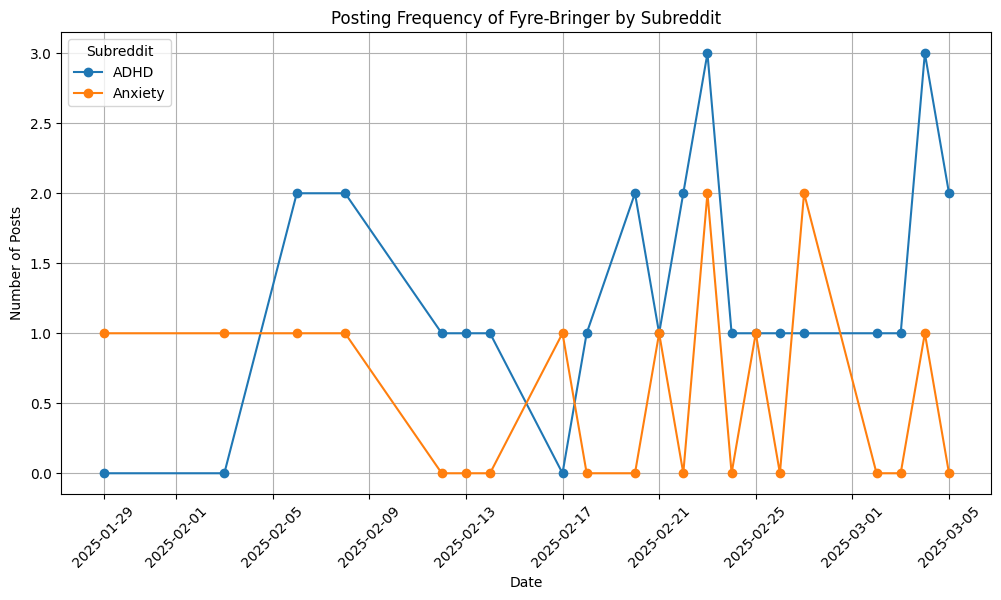

<ipython-input-19-5d202cca2511>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  author_df['Created_DateTime'] = pd.to_datetime(author_df['Created_DateTime'])
<ipython-input-19-5d202cca2511>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  author_df['Date'] = author_df['Created_DateTime'].dt.date


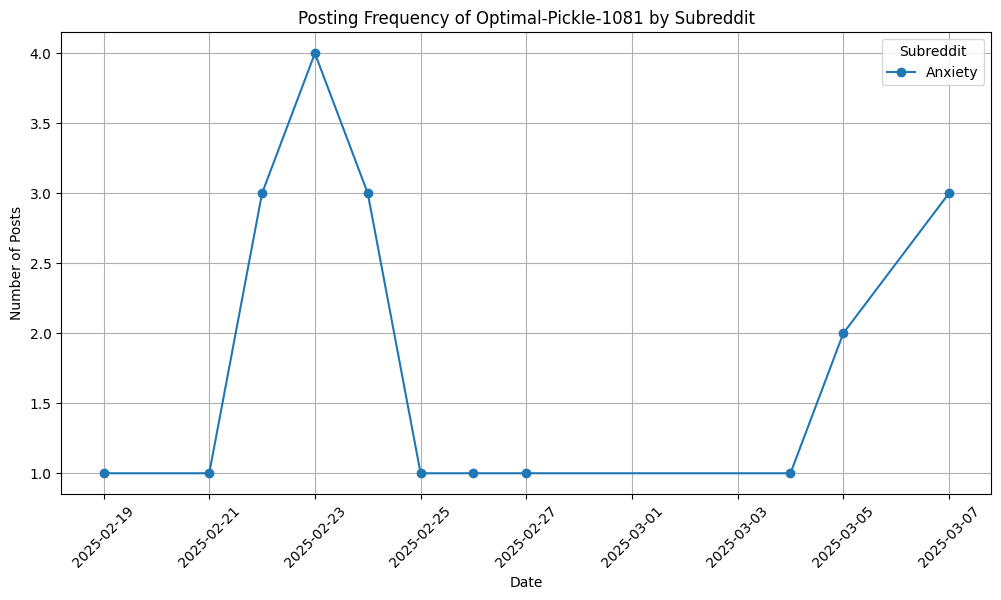

In [19]:
# 1️⃣2️⃣ Posting Frequency of Top 3 Authors by Subreddit
top_3_authors = top_authors.index[:3]
for author in top_3_authors:
    author_df = df[df['Author'] == author]
    author_df['Created_DateTime'] = pd.to_datetime(author_df['Created_DateTime'])
    author_df['Date'] = author_df['Created_DateTime'].dt.date
    author_posts = author_df.groupby(['Date', 'Subreddit']).size().unstack().fillna(0)
    author_posts.plot(kind='line', marker='o', figsize=(12, 6))
    plt.xlabel("Date")
    plt.ylabel("Number of Posts")
    plt.title(f"Posting Frequency of {author} by Subreddit")
    plt.xticks(rotation=45)
    plt.legend(title='Subreddit')
    plt.grid(True)
    plt.show()

In [20]:
print("Full EDA Completed Successfully!")

Full EDA Completed Successfully!


## Feature Engineering

In [ ]:
# -*- coding: utf-8 -*-
"""
Feature Engineering & Analysis on Reddit Mental Health Discussions Dataset

This script extracts meaningful features from Reddit discussions on mental health
and performs analysis to understand patterns in user engagement, sentiment, and subreddit activity.

Feature Engineering:
1. Text-Based Features
2. Sentiment Analysis
3. Time-Based Features
4. User Engagement Features
5. Keyword-Based Features (Medication Mentions)

Analysis:
1. Distribution of Post Lengths
2. Sentiment Distribution
3. User Activity Distribution
4. Subreddit Post Analysis
"""

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# Load dataset
file_path = "/mnt/data/reddit_posts_combined_26Jan_07Mar.csv"
df = pd.read_csv(file_path)

# Convert Created_DateTime to datetime format
df['Created_DateTime'] = pd.to_datetime(df['Created_DateTime'])

# 1️⃣ Text-Based Features
df['Word_Count_Selftext'] = df['Selftext'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df['Word_Count_Title'] = df['Title'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

df['Char_Count_Selftext'] = df['Selftext'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['Char_Count_Title'] = df['Title'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# 2️⃣ Sentiment Analysis using TextBlob
df['TextBlob_Sentiment'] = df['Selftext'].apply(lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0)

# 3️⃣ Time-Based Features
df['Day_of_Week'] = df['Created_DateTime'].dt.day_name()
df['Hour_of_Day'] = df['Created_DateTime'].dt.hour
df['Month'] = df['Created_DateTime'].dt.month

# 4️⃣ User Engagement Features
user_post_counts = df['Author'].value_counts().to_dict()
df['User_Post_Count'] = df['Author'].apply(lambda x: user_post_counts.get(x, 0))

user_avg_score = df.groupby('Author')['Score'].mean().to_dict()
df['User_Avg_Score'] = df['Author'].apply(lambda x: user_avg_score.get(x, 0))

# 5️⃣ Keyword-Based Features (Medication Mentions)
medications = {"prozac", "fluoxetine", "lexapro", "zoloft", "sertraline", "paxil", "celexa", "wellbutrin"}
df['Medications_Mentioned'] = df['Selftext'].apply(lambda x: ", ".join([word for word in str(x).lower().split() if word in medications]) if pd.notna(x) else "None")

# Save feature-engineered dataset
feature_engineered_file = "/mnt/data/reddit_posts_feature_engineered.csv"
df.to_csv(feature_engineered_file, index=False)

print(f"Feature engineered dataset saved at: {feature_engineered_file}")

# ========== 🔍 ANALYSIS ========== #

# 1️⃣ Distribution of Post Lengths
plt.figure(figsize=(10, 5))
sns.histplot(df['Word_Count_Selftext'], bins=50, kde=True)
plt.xlabel("Word Count in Selftext")
plt.ylabel("Number of Posts")
plt.title("Distribution of Post Lengths")
plt.show()

# 2️⃣ Sentiment Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['TextBlob_Sentiment'], bins=50, kde=True, color="purple")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Posts")
plt.title("Distribution of Sentiment Scores")
plt.show()

# 3️⃣ User Activity Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['User_Post_Count'], bins=50, kde=True, color="orange")
plt.xlabel("Number of Posts per User")
plt.ylabel("Frequency")
plt.title("User Activity Distribution")
plt.xscale("log")  # Log scale to handle skewness
plt.show()

# 4️⃣ Subreddit Post Analysis
plt.figure(figsize=(12, 5))
df['Subreddit'].value_counts().head(10).plot(kind='bar', color="skyblue")
plt.xlabel("Subreddit")
plt.ylabel("Number of Posts")
plt.title("Top 10 Active Subreddits")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

print("Feature Engineering and Analysis Completed Successfully!")